# Bitcoin Price Direction Classification
## Assignment 2 - Machine Learning Foundations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Data

In [2]:
df = pd.read_csv('btc.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f'Shape: {df.shape}')
df.head()

Shape: (366, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-02-18,52140.972656,52474.105469,51015.765625,51679.796875,51679.796875,52054723579
1,2021-02-19,51675.980469,56113.652344,50937.277344,55888.132813,55888.132813,63495496918
2,2021-02-20,55887.335938,57505.226563,54626.558594,56099.519531,56099.519531,68145460026
3,2021-02-21,56068.566406,58330.570313,55672.609375,57539.945313,57539.945313,51897585191
4,2021-02-22,57532.738281,57533.390625,48967.566406,54207.320313,54207.320313,92052420332


## 2. Feature Engineering

We engineer features from the raw OHLCV data. All features use only information available at time $t$ (no look-ahead bias).

| Feature | Formula | Description |
|---------|---------|-------------|
| `Return_1` | $\frac{C_t - C_{t-1}}{C_{t-1}} \times 100$ | Previous day's return (%) |
| `Return_2` | $\frac{C_{t-1} - C_{t-2}}{C_{t-2}} \times 100$ | Return from 2 days ago (%) |
| `Return_3` | $\frac{C_{t-2} - C_{t-3}}{C_{t-3}} \times 100$ | Return from 3 days ago (%) |
| `Volume_Change` | $\frac{V_t - V_{t-1}}{V_{t-1}} \times 100$ | Change in trading volume (%) |
| `HL_Spread` | $\frac{H_t - L_t}{C_t} \times 100$ | Intraday price range — volatility proxy (%) |
| `OC_Return` | $\frac{C_t - O_t}{O_t} \times 100$ | Intraday open-to-close return (%) |
| `MA5` | $\frac{1}{5}\sum_{k=0}^{4} C_{t-k}$ | 5-day simple moving average |
| `MA10` | $\frac{1}{10}\sum_{k=0}^{9} C_{t-k}$ | 10-day simple moving average |
| `MA20` | $\frac{1}{20}\sum_{k=0}^{19} C_{t-k}$ | 20-day simple moving average |
| `MA5_Ratio` | $\left(\frac{C_t}{\text{MA5}_t} - 1\right) \times 100$ | Short-term momentum vs 5-day avg (%) |
| `MA10_Ratio` | $\left(\frac{C_t}{\text{MA10}_t} - 1\right) \times 100$ | Medium-term momentum vs 10-day avg (%) |
| `Momentum_5` | $\frac{C_t - C_{t-5}}{C_{t-5}} \times 100$ | 5-day return (%) |
| `Gain` | $\max(\text{Return\_1},\; 0)$ | Positive return only, 0 otherwise |
| `Volatility_5` | $\text{std}(\text{Return\_1}_{t}, \ldots, \text{Return\_1}_{t-4})$ | 5-day rolling standard deviation of returns |
| `RSI_14` | $100 - \frac{100}{1 + RS}$, $RS = \frac{\text{AvgGain}_{14}}{\text{AvgLoss}_{14}}$ | Relative Strength Index (14-day) |
| `MACD` | $\text{EMA}_{12} - \text{EMA}_{26}$ | Moving Average Convergence Divergence |
| `MACD_Signal` | $\text{EMA}_9(\text{MACD})$ | MACD signal line |
| `MACD_Hist` | $\text{MACD} - \text{MACD\_Signal}$ | MACD histogram (momentum shift) |
| `BB_Position` | $\frac{C_t - BB^{lower}_t}{BB^{upper}_t - BB^{lower}_t}$ | Position within Bollinger Bands (0 to 1) |
| `DayOfWeek` | $0$ (Mon) to $6$ (Sun) | Day of the week |
| `Volume_Ratio` | $\frac{V_t}{\text{MA5}(V_t)}$ | Volume relative to its 5-day average |
| `Consec_Up` | $\sum_{k=0}^{4} \mathbb{1}(C_{t-k} > C_{t-k-1})$ | Number of up days in last 5 days |
| `Body` | $\frac{C_t - O_t}{O_t}$ | Candlestick body — normalized intraday directional move |
| `Upper_Shadow` | $\frac{H_t - \max(O_t, C_t)}{C_t}$ | Upper shadow — rejection from highs |
| `Lower_Shadow` | $\frac{\min(O_t, C_t) - L_t}{C_t}$ | Lower shadow — rejection from lows |
| `Shadow_Imbalance` | $\text{Lower\_Shadow} - \text{Upper\_Shadow}$ | Shadow imbalance — net buying/selling pressure |

**Target variable:**

| Target | Formula | Description |
|--------|---------|-------------|
| `Direction` | $\mathbb{1}(C_{t+1} > C_t)$ | 1 if next day's close is higher, 0 otherwise |

Where $C_t$ = Close, $O_t$ = Open, $H_t$ = High, $L_t$ = Low, $V_t$ = Volume at day $t$.

In [3]:
# Lagged Returns
df['Return_1'] = df['Close'].pct_change(1) * 100
df['Return_2'] = df['Return_1'].shift(1)
df['Return_3'] = df['Return_1'].shift(2)

# Volume
df['Volume_Change'] = df['Volume'].pct_change(1) * 100

# Intraday
df['HL_Spread'] = (df['High'] - df['Low']) / df['Close'] * 100
df['OC_Return'] = (df['Close'] - df['Open']) / df['Open'] * 100

# Moving Averages
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

# Momentum / Trend
df['MA5_Ratio'] = (df['Close'] / df['MA5'] - 1) * 100
df['MA10_Ratio'] = (df['Close'] / df['MA10'] - 1) * 100
df['Momentum_5'] = df['Close'].pct_change(5) * 100

# Gain
df['Gain'] = df['Return_1'].clip(lower=0)

# Volatility
df['Volatility_5'] = df['Return_1'].rolling(window=5).std()

# RSI (Relative Strength Index, 14-day)
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -delta.clip(upper=0)
avg_gain = up.rolling(window=14).mean()
avg_loss = down.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

# Bollinger Bands (20-day)
bb_ma = df['Close'].rolling(window=20).mean()
bb_std = df['Close'].rolling(window=20).std()
df['BB_Upper'] = bb_ma + 2 * bb_std
df['BB_Lower'] = bb_ma - 2 * bb_std
df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

# Day of Week (0=Mon, 6=Sun)
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Volume MA Ratio
df['Volume_MA5'] = df['Volume'].rolling(window=5).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_MA5']

# Consecutive Up/Down Days
df['Up_Day'] = (df['Close'] > df['Close'].shift(1)).astype(int)
df['Consec_Up'] = df['Up_Day'].rolling(window=5).sum()

# Body
df["Body"] = (df["Close"] - df["Open"]) / df["Open"]

# Upper Shadow
df["Upper_Shadow"] = (
    df["High"] - df[["Open", "Close"]].max(axis=1)
) / df["Close"]

# Lower Shadow
df["Lower_Shadow"] = (
    df[["Open", "Close"]].min(axis=1) - df["Low"]
) / df["Close"]

# Shadow imbalance
df["Shadow_Imbalance"] = df["Lower_Shadow"] - df["Upper_Shadow"]

# --- Target: did the price go UP the next day? ---
df['Direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [4]:
# Drop NaN rows (from lags/rolling/target)
df_clean = df.dropna().reset_index(drop=True)
print(f'Clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns')
df_clean.head()

Clean dataset: 347 rows, 38 columns


,Date,Open,High,Low,Close,Adj Close,Volume,Return_1,Return_2,Return_3,...,DayOfWeek,Volume_MA5,Volume_Ratio,Up_Day,Consec_Up,Body,Upper_Shadow,Lower_Shadow,Shadow_Imbalance,Direction
0,2021-03-09,52272.968750,54824.117188,51981.832031,54824.117188,54824.117188,50912227385,4.933522,2.030657,4.690650,...,1,4.512732e+10,1.128191,1,4.0,0.048804,0.000000,0.005310,0.005310,1
1,2021-03-10,54824.011719,57258.253906,53290.890625,56008.550781,56008.550781,57295577614,2.160424,4.933522,2.030657,...,2,4.686125e+10,1.222664,1,4.0,0.021606,0.022313,0.027373,0.005060,1
2,2021-03-11,55963.179688,58091.062500,54484.593750,57805.121094,57805.121094,56772343595,3.207671,2.160424,4.933522,...,3,5.134301e+10,1.105746,1,5.0,0.032913,0.004947,0.025579,0.020632,0
3,2021-03-12,57821.218750,57996.621094,55376.648438,57332.089844,57332.089844,55689944702,-0.818321,3.207671,2.160424,...,4,5.385350e+10,1.034101,0,4.0,-0.008459,0.003059,0.034107,0.031048,1
4,2021-03-13,57343.371094,61683.863281,56217.972656,61243.085938,61243.085938,60669829814,6.821653,-0.818321,3.207671,...,5,5.626798e+10,1.078230,1,4.0,0.068006,0.007197,0.018376,0.011179,0


## 3. Exploratory Data Analysis

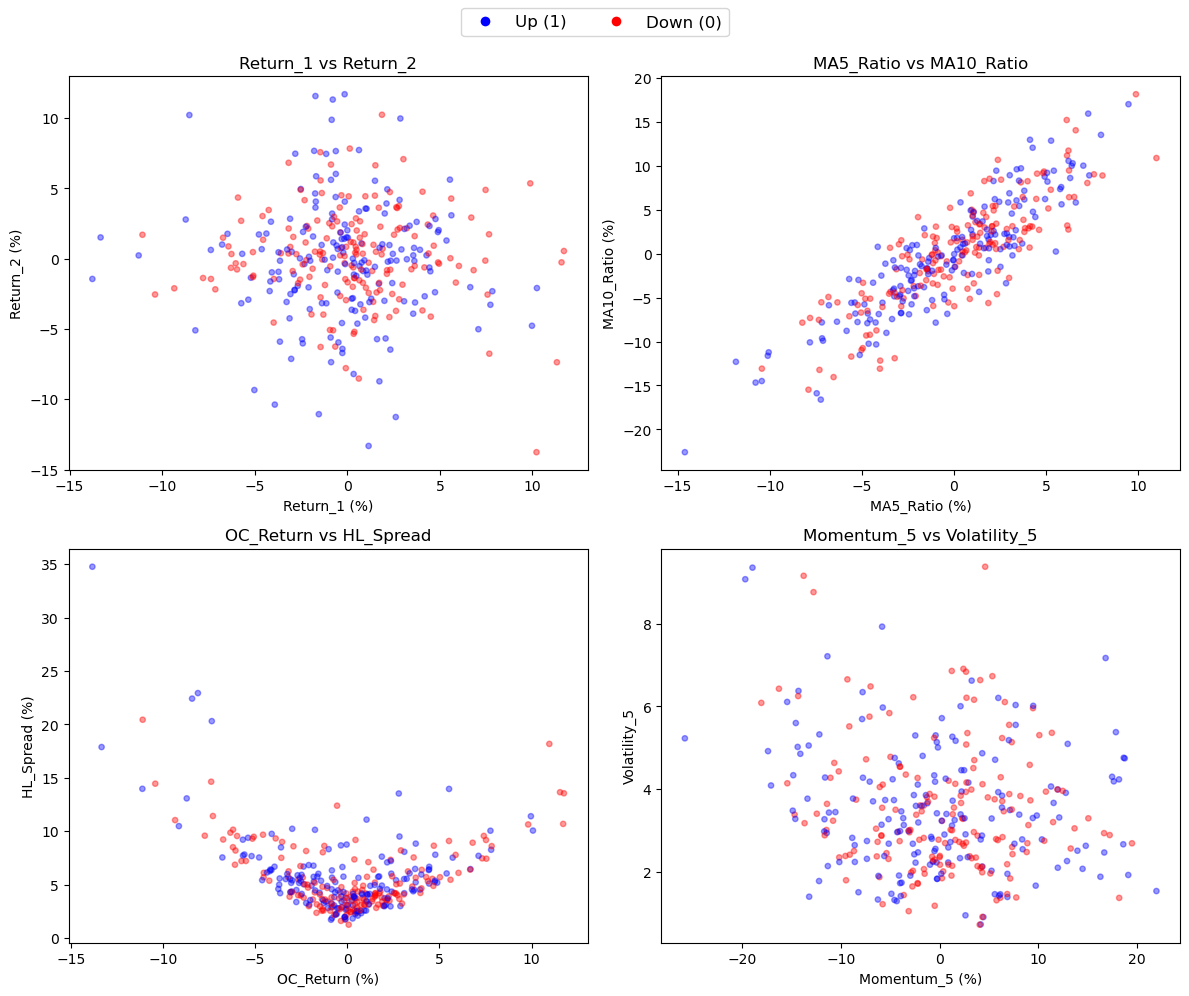

In [5]:
# Scatter plots of key feature pairs, colored by Direction
colors = df_clean['Direction'].map({0: 'red', 1: 'blue'})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Return_1 vs Return_2 (as in lecture notes)
axes[0, 0].scatter(df_clean['Return_1'], df_clean['Return_2'], c=colors, alpha=0.4, s=15)
axes[0, 0].set_xlabel('Return_1 (%)')
axes[0, 0].set_ylabel('Return_2 (%)')
axes[0, 0].set_title('Return_1 vs Return_2')

# Plot 2: MA5_Ratio vs MA10_Ratio
axes[0, 1].scatter(df_clean['MA5_Ratio'], df_clean['MA10_Ratio'], c=colors, alpha=0.4, s=15)
axes[0, 1].set_xlabel('MA5_Ratio (%)')
axes[0, 1].set_ylabel('MA10_Ratio (%)')
axes[0, 1].set_title('MA5_Ratio vs MA10_Ratio')

# Plot 3: OC_Return vs HL_Spread
axes[1, 0].scatter(df_clean['OC_Return'], df_clean['HL_Spread'], c=colors, alpha=0.4, s=15)
axes[1, 0].set_xlabel('OC_Return (%)')
axes[1, 0].set_ylabel('HL_Spread (%)')
axes[1, 0].set_title('OC_Return vs HL_Spread')

# Plot 4: Momentum_5 vs Volatility_5
axes[1, 1].scatter(df_clean['Momentum_5'], df_clean['Volatility_5'], c=colors, alpha=0.4, s=15)
axes[1, 1].set_xlabel('Momentum_5 (%)')
axes[1, 1].set_ylabel('Volatility_5')
axes[1, 1].set_title('Momentum_5 vs Volatility_5')

# Add shared legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Up (1)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Down (0)')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

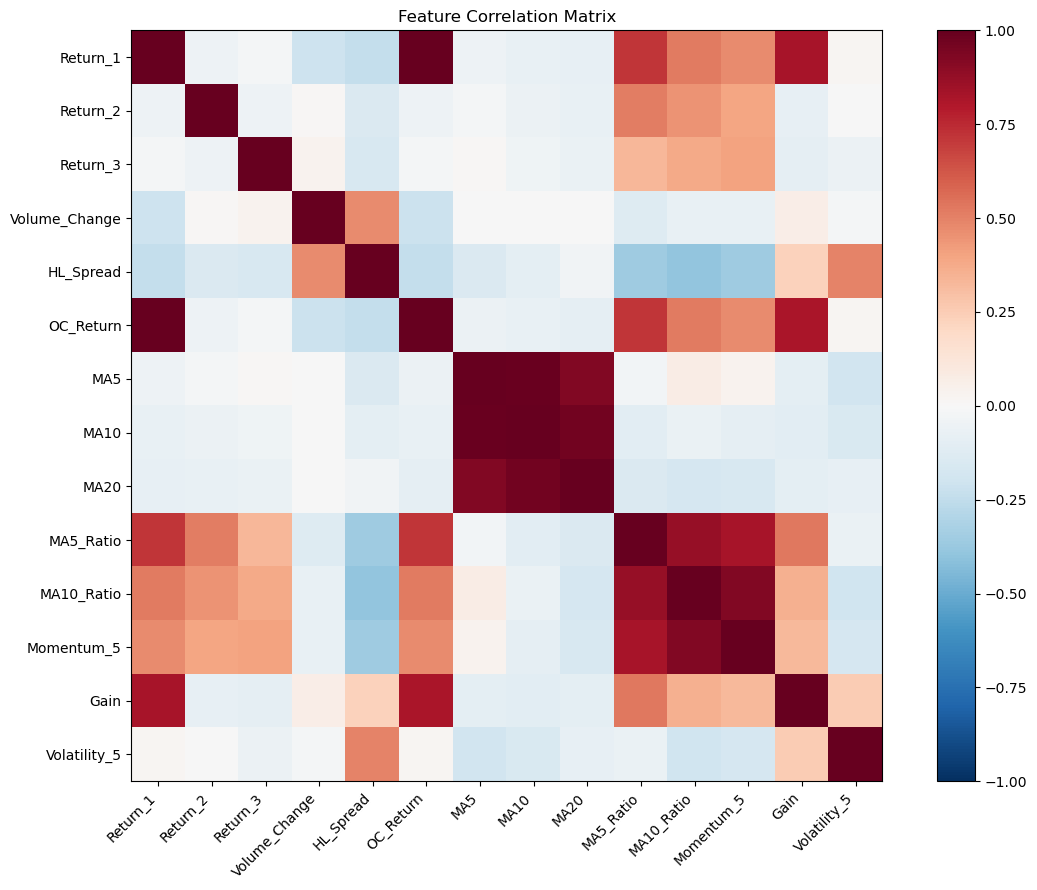

In [6]:
# Correlation heatmap of features
feature_cols = ['Return_1', 'Return_2', 'Return_3', 'Volume_Change',
                'HL_Spread', 'OC_Return', 'MA5', 'MA10', 'MA20',
                'MA5_Ratio', 'MA10_Ratio', 'Momentum_5', 'Gain', 'Volatility_5']

fig, ax = plt.subplots(figsize=(12, 9))
corr = df_clean[feature_cols].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_yticklabels(feature_cols)
plt.colorbar(im)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Interpretation of the Correlation Heatmap

**Highly correlated feature groups (multicollinearity):**

- **MA5, MA10, MA20** are near-perfectly correlated ($\approx 1.0$) with each other. This is expected since they are all smoothed versions of the same Close price series over overlapping windows. Including all three may introduce redundancy — we may consider keeping only one or using the ratio versions instead.

- **MA5_Ratio, MA10_Ratio, and Momentum_5** are strongly positively correlated. All three capture momentum/trend from different angles (deviation from moving average vs. 5-day return), so they carry overlapping information.

- **Return_1 and Gain** are highly correlated, since Gain is simply the positive part of Return_1 (i.e., $\max(\text{Return\_1}, 0)$). They are not identical however — Gain zeroes out negative returns, adding asymmetric information.

- **Return_1 and OC_Return** show moderate positive correlation. Both measure a daily price change, but Return_1 is close-to-close while OC_Return is open-to-close within the same day.

**Low/no correlation (independent information):**

- **Return_2 and Return_3** (lagged returns) show weak correlation with Return_1, suggesting BTC daily returns are not strongly autocorrelated — consistent with efficient market behavior.

- **Volume_Change** has low correlation with most other features, meaning it captures a different dimension of market activity.

**Volatility cluster:**

- **HL_Spread and Volatility_5** are moderately positively correlated — both measure market turbulence, but via different mechanisms (intraday range vs. rolling return dispersion).

**Implication for modeling:** The high correlation among MA5/MA10/MA20 and among momentum features means some features carry redundant information. This is not necessarily a problem for classification methods like LDA and Logistic Regression, but it is worth noting. We will use the ratio versions (MA5_Ratio, MA10_Ratio) rather than the raw moving averages as predictors to reduce redundancy.

## 4. Train / Test Split

We use a **temporal split** (no shuffling) to avoid look-ahead bias. First 80% for training, last 20% for testing.

In [7]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['Return_1', 'Return_2', 'Return_3', 'Volume_Change',
                'HL_Spread', 'OC_Return', 'MA5', 'MA10', 'MA20',
                'MA5_Ratio', 'MA10_Ratio', 'Momentum_5', 'Gain', 'Volatility_5', 'Body', 'Upper_Shadow', 'Lower_Shadow']

X = df_clean[feature_cols].values
y = df_clean['Direction'].values

# Temporal 80/20 split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Standardize (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Features used ({len(feature_cols)}): {feature_cols}')
print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')
print(f'\nTrain date range: {df_clean["Date"].iloc[0].date()} to {df_clean["Date"].iloc[split_idx-1].date()}')
print(f'Test date range:  {df_clean["Date"].iloc[split_idx].date()} to {df_clean["Date"].iloc[-1].date()}')
print(f'\nTrain class balance: {y_train.mean():.3f} (proportion up days)')
print(f'Test class balance:  {y_test.mean():.3f} (proportion up days)')

Features used (17): ['Return_1', 'Return_2', 'Return_3', 'Volume_Change', 'HL_Spread', 'OC_Return', 'MA5', 'MA10', 'MA20', 'MA5_Ratio', 'MA10_Ratio', 'Momentum_5', 'Gain', 'Volatility_5', 'Body', 'Upper_Shadow', 'Lower_Shadow']

Training set: 277 samples
Testing set:  70 samples

Train date range: 2021-03-09 to 2021-12-10
Test date range:  2021-12-11 to 2022-02-18

Train class balance: 0.509 (proportion up days)
Test class balance:  0.471 (proportion up days)


## 5. Classification Method 1: Linear Discriminant Analysis (LDA)

LDA assumes that $X | Y = j \sim N_p(\mu_j, \Sigma)$ with a **common** covariance matrix $\Sigma$ across classes. The decision rule is:

$$f^*_{\text{lda}}(x) = \arg\max_{i=1,\ldots,K} \left[ x'\hat{\Sigma}^{-1}\hat{\mu}_i - \frac{1}{2}\hat{\mu}_i'\hat{\Sigma}^{-1}\hat{\mu}_i + \log(\hat{\pi}_i) \right]$$

This produces a **linear** decision boundary.

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)

y_pred_lda_train = lda.predict(X_train_s)
y_pred_lda_test = lda.predict(X_test_s)

print('=== LDA Results ===')
print(f'Training accuracy: {accuracy_score(y_train, y_pred_lda_train):.4f}')
print(f'Testing accuracy:  {accuracy_score(y_test, y_pred_lda_test):.4f}')
print(f'\nConfusion Matrix (Test):')
print(confusion_matrix(y_test, y_pred_lda_test))
print(f'\nClassification Report (Test):')
print(classification_report(y_test, y_pred_lda_test, target_names=['Down (0)', 'Up (1)']))

=== LDA Results ===
Training accuracy: 0.5848
Testing accuracy:  0.5286

Confusion Matrix (Test):
[[10 27]
 [ 6 27]]

Classification Report (Test):
              precision    recall  f1-score   support

    Down (0)       0.62      0.27      0.38        37
      Up (1)       0.50      0.82      0.62        33

    accuracy                           0.53        70
   macro avg       0.56      0.54      0.50        70
weighted avg       0.57      0.53      0.49        70



## 6. Classification Method 2: Quadratic Discriminant Analysis (QDA)

Unlike LDA, QDA allows each class to have its **own** covariance matrix $\Sigma_j$. The decision rule is:

$$f^*_{\text{qda}}(x) = \arg\max_{i=1,\ldots,K} \left[ -\frac{1}{2}\log(\det(\hat{\Sigma}_i)) - \frac{1}{2}(x - \hat{\mu}_i)'\hat{\Sigma}_i^{-1}(x - \hat{\mu}_i) + \log(\hat{\pi}_i) \right]$$

This produces a **quadratic** (non-linear) decision boundary, which is more flexible than LDA but may overfit with limited data.

In [9]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda.fit(X_train_s, y_train)

y_pred_qda_train = qda.predict(X_train_s)
y_pred_qda_test = qda.predict(X_test_s)

print('=== QDA Results ===')
print(f'Training accuracy: {accuracy_score(y_train, y_pred_qda_train):.4f}')
print(f'Testing accuracy:  {accuracy_score(y_test, y_pred_qda_test):.4f}')
print(f'\nConfusion Matrix (Test):')
print(confusion_matrix(y_test, y_pred_qda_test))
print(f'\nClassification Report (Test):')
print(classification_report(y_test, y_pred_qda_test, target_names=['Down (0)', 'Up (1)']))

=== QDA Results ===
Training accuracy: 0.6029
Testing accuracy:  0.6429

Confusion Matrix (Test):
[[22 15]
 [10 23]]

Classification Report (Test):
              precision    recall  f1-score   support

    Down (0)       0.69      0.59      0.64        37
      Up (1)       0.61      0.70      0.65        33

    accuracy                           0.64        70
   macro avg       0.65      0.65      0.64        70
weighted avg       0.65      0.64      0.64        70



## 7. Classification Method 3: Logistic Regression (LRC)

Logistic regression models the conditional probability directly:

$$P(Y=1 | X=x) = \frac{\exp(x'\beta)}{1 + \exp(x'\beta)}$$

The decision rule classifies $x$ as 1 if $P(Y=1|x) \geq 0.5$, equivalently if $x'\hat{\beta} \geq 0$. This also produces a **linear** decision boundary, but is derived from a different modeling assumption than LDA (cf. Section 4 of the lecture notes).

In [10]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)

y_pred_lr_train = logreg.predict(X_train_s)
y_pred_lr_test = logreg.predict(X_test_s)

print('=== Logistic Regression Results ===')
print(f'Training accuracy: {accuracy_score(y_train, y_pred_lr_train):.4f}')
print(f'Testing accuracy:  {accuracy_score(y_test, y_pred_lr_test):.4f}')
print(f'\nConfusion Matrix (Test):')
print(confusion_matrix(y_test, y_pred_lr_test))
print(f'\nClassification Report (Test):')
print(classification_report(y_test, y_pred_lr_test, target_names=['Down (0)', 'Up (1)']))

=== Logistic Regression Results ===
Training accuracy: 0.5848
Testing accuracy:  0.4857

Confusion Matrix (Test):
[[ 9 28]
 [ 8 25]]

Classification Report (Test):
              precision    recall  f1-score   support

    Down (0)       0.53      0.24      0.33        37
      Up (1)       0.47      0.76      0.58        33

    accuracy                           0.49        70
   macro avg       0.50      0.50      0.46        70
weighted avg       0.50      0.49      0.45        70



##  Feature Importance (Logistic Regression Coefficients)

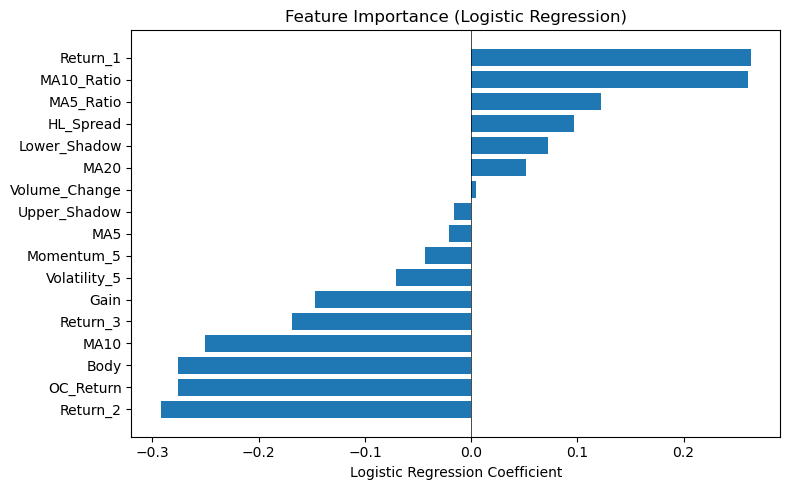

In [11]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': logreg.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Logistic Regression Coefficient')
plt.title('Feature Importance (Logistic Regression)')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. Additional Classification Methods

### 8.1 Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_s, y_train)

y_pred_dt_train = dt.predict(X_train_s)
y_pred_dt_test = dt.predict(X_test_s)

print('=== Decision Tree Results ===')
print(f'Training accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}')
print(f'Testing accuracy:  {accuracy_score(y_test, y_pred_dt_test):.4f}')
print(f'\nConfusion Matrix (Test):')
print(confusion_matrix(y_test, y_pred_dt_test))
print(f'\nClassification Report (Test):')
print(classification_report(y_test, y_pred_dt_test, target_names=['Down (0)', 'Up (1)']))

=== Decision Tree Results ===
Training accuracy: 0.7509
Testing accuracy:  0.5143

Confusion Matrix (Test):
[[24 13]
 [21 12]]

Classification Report (Test):
              precision    recall  f1-score   support

    Down (0)       0.53      0.65      0.59        37
      Up (1)       0.48      0.36      0.41        33

    accuracy                           0.51        70
   macro avg       0.51      0.51      0.50        70
weighted avg       0.51      0.51      0.50        70



### 8.2 Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train_s, y_train)

y_pred_rf_train = rf.predict(X_train_s)
y_pred_rf_test = rf.predict(X_test_s)

print('=== Random Forest Results ===')
print(f'Training accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}')
print(f'Testing accuracy:  {accuracy_score(y_test, y_pred_rf_test):.4f}')
print(f'\nConfusion Matrix (Test):')
print(confusion_matrix(y_test, y_pred_rf_test))
print(f'\nClassification Report (Test):')
print(classification_report(y_test, y_pred_rf_test, target_names=['Down (0)', 'Up (1)']))

=== Random Forest Results ===
Training accuracy: 0.9495
Testing accuracy:  0.5571

Confusion Matrix (Test):
[[20 17]
 [14 19]]

Classification Report (Test):
              precision    recall  f1-score   support

    Down (0)       0.59      0.54      0.56        37
      Up (1)       0.53      0.58      0.55        33

    accuracy                           0.56        70
   macro avg       0.56      0.56      0.56        70
weighted avg       0.56      0.56      0.56        70



## 9. Comparison of All Methods

In [14]:
# Summary table
results = pd.DataFrame({
    'Method': ['LDA', 'Logistic Regression', 'QDA', 'Decision Tree', 'Random Forest'],
    'Train Accuracy': [
        accuracy_score(y_train, y_pred_lda_train),
        accuracy_score(y_train, y_pred_lr_train),
        accuracy_score(y_train, y_pred_qda_train),
        accuracy_score(y_train, y_pred_dt_train),
        accuracy_score(y_train, y_pred_rf_train)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_lda_test),
        accuracy_score(y_test, y_pred_lr_test),
        accuracy_score(y_test, y_pred_qda_test),
        accuracy_score(y_test, y_pred_dt_test),
        accuracy_score(y_test, y_pred_rf_test)    ]
})
results['Overfit Gap'] = results['Train Accuracy'] - results['Test Accuracy']
results = results.sort_values('Test Accuracy', ascending=False)
print(results.to_string(index=False))

             Method  Train Accuracy  Test Accuracy  Overfit Gap
                QDA        0.602888       0.642857    -0.039969
      Random Forest        0.949458       0.557143     0.392316
                LDA        0.584838       0.528571     0.056266
      Decision Tree        0.750903       0.514286     0.236617
Logistic Regression        0.584838       0.485714     0.099123


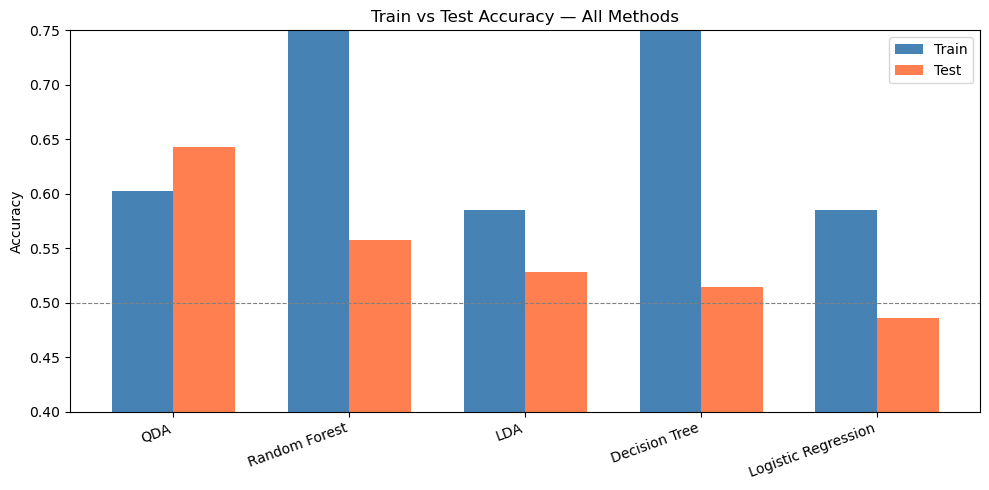

In [15]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results))
width = 0.35
ax.bar([i - width/2 for i in x], results['Train Accuracy'], width, label='Train', color='steelblue')
ax.bar([i + width/2 for i in x], results['Test Accuracy'], width, label='Test', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results['Method'], rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy — All Methods')
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (50%)')
ax.set_ylim(0.4, 0.75)
plt.tight_layout()
plt.show()

## 10. Discussion

**Summary of results:**

| Method | Train Accuracy | Test Accuracy | Overfit Gap |
|--------|---------------|---------------|-------------|
| QDA | 60.3% | **64.3%** | −4.0% |
| Random Forest | 94.9% | 55.7% | +39.2% |
| LDA | 58.5% | 52.9% | +5.6% |
| Decision Tree | 75.1% | 51.4% | +23.7% |
| Logistic Regression | 58.5% | 48.6% | +9.9% |

**Key observations:**

1. **QDA is the clear best performer**, achieving 64.3% test accuracy — the only method meaningfully above the 50% random-guessing baseline. Notably, QDA exhibits a *negative* overfit gap (−4.0%), meaning it generalizes better than its training performance would suggest. This indicates that the two classes (up vs. down days) have genuinely different covariance structures in feature space, and that the quadratic decision boundary captures this heterogeneity more faithfully than a linear one.

2. **LDA and Logistic Regression** achieve identical training accuracy (58.5%), which is expected from theory — both produce linear decision boundaries, derived from different modeling assumptions (generative vs. discriminative). However, on the test set LDA slightly outperforms Logistic Regression (52.9% vs. 48.6%). Logistic Regression falls *below* the 50% baseline, suggesting that the linear boundary it learned on the training data does not transfer well to the test period. This is consistent with the possibility that the linear separability present in training data weakens or shifts in the test window.

3. **Random Forest** exhibits the most severe overfitting of all methods, with a 39.2 percentage-point gap between training (94.9%) and test (55.7%) accuracy. Despite using 200 trees and `max_depth=5`, the ensemble memorizes the training set almost perfectly but captures very little generalizable signal. This is a textbook case of overfitting on noisy, weakly-patterned data.

4. **Decision Tree** similarly overfits (75.1% train vs. 51.4% test), confirming that tree-based methods are particularly susceptible to fitting noise in low signal-to-noise financial data, even with depth constraints.

5. The **overfit gap** is a crucial diagnostic. The three methods with the smallest gaps — QDA (−4.0%), LDA (+5.6%), and Logistic Regression (+9.9%) — are all parametric models with relatively low capacity, while the tree-based methods (Decision Tree: +23.7%, Random Forest: +39.2%) have far higher capacity and correspondingly larger gaps. This illustrates the **bias-variance tradeoff**: more flexible models can fit training data better but generalize worse when the true signal is weak.

6. Achieving >60% accuracy on BTC daily direction prediction is inherently challenging because financial markets are highly efficient — past price information is quickly absorbed, making prediction from historical data alone very difficult. That QDA reaches 64.3% is a moderately encouraging result, possibly reflecting genuine non-linear structure in the class-conditional distributions that simpler linear methods miss.